# AQSOL Graph Property Prediction - LPE Ablation Across GATv2, GraphGPS, AttentiveFP, and GCN

This notebook trains and benchmarks four GNN models (GATv2, GraphGPS, AttentiveFP, GCN) on the AQSOL dataset from OGB.

Each model is evaluated in two variants: with Laplacian positional encodings (+LPE) and without Laplacian positional encodings (-LPE).

Task: Predict aqueous solubility (log mol/L) of molecules - a graph-level regression problem.

Primary metric: RMSE (lower is better).

## 1. Install Dependencies

In [1]:
%pip install ogb
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
%pip install torch_geometric
%pip install optuna
%pip install scipy matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 3.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 2. Dataset Loading — AQSOL

In [2]:
import torch
import torch_geometric
from torch_geometric.loader import DataLoader
from torch_geometric.datasets import AQSOL

dataset = AQSOL(root='data/AQSOL')

sample = dataset[0]
print("sample:", sample)
print("x shape:", sample.x.shape)
print("x dtype:", sample.x.dtype)

# AQSOL stores x as [num_nodes] (1D integer atom indices) OR [num_nodes, F]
# Handle both cases:
if sample.x.dim() == 1:
    # 1D: single integer feature per node — treat as 1-dim float feature
    NODE_DIM = 1
    print("Note: x is 1D — will unsqueeze to [N,1] in model forward()")
else:
    NODE_DIM = sample.x.shape[1]

if sample.edge_attr is None:
    EDGE_DIM = 0
    print("Note: no edge_attr — edge features will be skipped")
elif sample.edge_attr.dim() == 1:
    EDGE_DIM = 1
    print("Note: edge_attr is 1D — will unsqueeze to [E,1] in model forward()")
else:
    EDGE_DIM = sample.edge_attr.shape[1]

print(f'Dataset: {dataset}')
print(f'Number of graphs : {len(dataset)}')
print(f'NODE_DIM: {NODE_DIM}')
print(f'EDGE_DIM: {EDGE_DIM}')

total = len(dataset)
train_size = int(0.8 * total)
val_size   = int(0.1 * total)
test_size  = total - train_size - val_size

train_dataset = dataset[:train_size]
val_dataset   = dataset[train_size:train_size + val_size]
test_dataset  = dataset[train_size + val_size:]

print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}')

Extracting data/AQSOL/aqsol_graph_raw.zip
Processing...


sample: Data(x=[23], edge_index=[2, 42], edge_attr=[42], y=[1])
x shape: torch.Size([23])
x dtype: torch.int64
Note: x is 1D — will unsqueeze to [N,1] in model forward()
Note: edge_attr is 1D — will unsqueeze to [E,1] in model forward()
Dataset: AQSOL(7836)
Number of graphs : 7836
NODE_DIM: 1
EDGE_DIM: 1
Train: 6268, Val: 783, Test: 785


Done!


In [3]:
import torch
import numpy as np
from pathlib import Path
from torch_geometric.utils import get_laplacian, to_scipy_sparse_matrix
from scipy.sparse.linalg import eigsh
from tqdm import tqdm

LAP_PE_DIM = 20   # number of Laplacian eigenvectors
PE_CACHE_PATH = Path(f"data/AQSOL/lap_pe_cache_k{LAP_PE_DIM}.pt")


def compute_laplacian_pe(data, k=LAP_PE_DIM):
    """Compute k smallest non-trivial Laplacian eigenvectors for one graph."""
    num_nodes = data.num_nodes

    edge_index, edge_weight = get_laplacian(
        data.edge_index, normalization='sym', num_nodes=num_nodes
    )
    L = to_scipy_sparse_matrix(edge_index, edge_weight, num_nodes)

    k_actual = min(k, num_nodes - 2)

    if k_actual < 1:
        pe = np.zeros((num_nodes, k), dtype=np.float32)
    else:
        try:
            _, eigenvectors = eigsh(L, k=k_actual + 1, which='SM')
            eigenvectors = eigenvectors[:, 1:k_actual + 1]
            if eigenvectors.shape[1] < k:
                pad = np.zeros((num_nodes, k - eigenvectors.shape[1]), dtype=np.float32)
                eigenvectors = np.concatenate([eigenvectors, pad], axis=1)
            pe = eigenvectors[:, :k].astype(np.float32)
        except Exception:
            pe = np.zeros((num_nodes, k), dtype=np.float32)

    data.lap_pe = torch.tensor(pe, dtype=torch.float)
    return data


def attach_cached_pe(split_dataset, pe_list):
    out = []
    for d, pe in zip(split_dataset, pe_list):
        d.lap_pe = pe
        out.append(d)
    return out


loaded_from_cache = False
if PE_CACHE_PATH.exists():
    try:
        cache = torch.load(PE_CACHE_PATH)
        expected = (
            cache.get("k") == LAP_PE_DIM
            and len(cache.get("train_pe", [])) == len(train_dataset)
            and len(cache.get("val_pe", [])) == len(val_dataset)
            and len(cache.get("test_pe", [])) == len(test_dataset)
        )
        if expected:
            train_dataset = attach_cached_pe(train_dataset, cache["train_pe"] )
            val_dataset = attach_cached_pe(val_dataset, cache["val_pe"] )
            test_dataset = attach_cached_pe(test_dataset, cache["test_pe"] )
            loaded_from_cache = True
            print(f"Loaded Laplacian PE from cache: {PE_CACHE_PATH}")
    except Exception as e:
        print(f"PE cache load failed, recomputing. Reason: {e}")

if not loaded_from_cache:
    print("Computing Laplacian PE for train...")
    train_dataset = [compute_laplacian_pe(d) for d in tqdm(train_dataset)]
    print("Computing Laplacian PE for val...")
    val_dataset = [compute_laplacian_pe(d) for d in tqdm(val_dataset)]
    print("Computing Laplacian PE for test...")
    test_dataset = [compute_laplacian_pe(d) for d in tqdm(test_dataset)]

    PE_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "k": LAP_PE_DIM,
            "train_pe": [d.lap_pe.cpu() for d in train_dataset],
            "val_pe": [d.lap_pe.cpu() for d in val_dataset],
            "test_pe": [d.lap_pe.cpu() for d in test_dataset],
        },
        PE_CACHE_PATH,
    )
    print(f"Saved Laplacian PE cache to: {PE_CACHE_PATH}")

print(f"PE shape on first graph: {train_dataset[0].lap_pe.shape}")

Computing Laplacian PE for train...


100%|██████████| 6268/6268 [00:07<00:00, 864.34it/s]


Computing Laplacian PE for val...


100%|██████████| 783/783 [00:01<00:00, 761.85it/s]


Computing Laplacian PE for test...


100%|██████████| 785/785 [00:01<00:00, 764.34it/s]


Saved Laplacian PE cache to: data/AQSOL/lap_pe_cache_k20.pt
PE shape on first graph: torch.Size([23, 20])


## 3. Device Setup

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 4. Shared Utilities

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch_geometric.nn import global_mean_pool
from torch_geometric.nn.aggr import AttentionalAggregation   # replaces deprecated GlobalAttention

# ------------------------------------------------------------------ #
#  Attention pooling factory (shared by both models)                  #
# ------------------------------------------------------------------ #
def make_att_pool(emb_dim):
    gate = nn.Sequential(
        nn.Linear(emb_dim, emb_dim),
        nn.LayerNorm(emb_dim),
        nn.ReLU(),
        nn.Linear(emb_dim, emb_dim // 2),
        nn.ReLU(),
        nn.Linear(emb_dim // 2, 1)
    )
    return AttentionalAggregation(gate_nn=gate)


# ------------------------------------------------------------------ #
#  Regression head (shared by both models)                            #
# ------------------------------------------------------------------ #
class RegressionHead(nn.Module):
    def __init__(self, emb_dim, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(emb_dim, emb_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim // 2, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)  # [B]


# ------------------------------------------------------------------ #
#  RMSE metric                                                        #
# ------------------------------------------------------------------ #
def rmse(preds, targets):
    return torch.sqrt(F.mse_loss(preds, targets)).item()

## 5. Model A — GATv2 Encoder

GATv2 (Brody et al., 2022) fixes the expressivity limitation of the original GAT by computing dynamic attention — the attention score depends on both source and target node features jointly, not independently.

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, GraphNorm
from torch_geometric.nn.aggr import AttentionalAggregation


class GATv2Encoder(nn.Module):
    def __init__(self, node_in_dim, edge_in_dim, emb_dim=128,
                 num_layers=4, heads=4, dropout=0.2,
                 lap_pe_dim=20, use_att_pool=True, use_lpe=True):
        super().__init__()

        self.dropout = dropout
        self.use_att_pool = use_att_pool
        self.use_lpe = use_lpe
        self.lap_pe_dim = lap_pe_dim if use_lpe else 0

        assert emb_dim % heads == 0
        head_dim = emb_dim // heads

        # Project node features (optionally concatenated with Laplacian PE).
        self.node_proj = nn.Linear(node_in_dim + self.lap_pe_dim, emb_dim)

        if edge_in_dim > 0:
            self.edge_proj = nn.Linear(edge_in_dim, emb_dim)
            gatv2_edge_dim = emb_dim
        else:
            self.edge_proj = None
            gatv2_edge_dim = None

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(GATv2Conv(
                in_channels=emb_dim, out_channels=head_dim,
                heads=heads, edge_dim=gatv2_edge_dim,
                concat=True, dropout=dropout, add_self_loops=False,
            ))
            self.norms.append(GraphNorm(emb_dim))

        self.pool = make_att_pool(emb_dim) if use_att_pool else global_mean_pool

    def forward(self, x, edge_index, edge_attr, batch, lap_pe=None):
        if x.dim() == 1:
            x = x.unsqueeze(-1)

        if self.use_lpe:
            if lap_pe is None:
                lap_pe = torch.zeros(x.size(0), self.lap_pe_dim, device=x.device, dtype=torch.float)
            x = torch.cat([x.float(), lap_pe.float()], dim=-1)
        else:
            x = x.float()

        x = self.node_proj(x)

        if self.edge_proj is not None and edge_attr is not None:
            if edge_attr.dim() == 1:
                edge_attr = edge_attr.unsqueeze(-1)
            e = self.edge_proj(edge_attr.float())
        else:
            e = None

        for conv, norm in zip(self.convs, self.norms):
            h = conv(x, edge_index, edge_attr=e)
            h = F.elu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
            x = norm(x + h)

        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.pool(x, batch)


class GATv2Model(nn.Module):
    def __init__(self, node_in_dim, edge_in_dim, emb_dim=128,
                 num_layers=4, heads=4, dropout=0.2,
                 lap_pe_dim=LAP_PE_DIM, use_lpe=True):
        super().__init__()
        self.encoder = GATv2Encoder(
            node_in_dim, edge_in_dim, emb_dim, num_layers,
            heads, dropout, lap_pe_dim, True, use_lpe
        )
        self.head = RegressionHead(emb_dim, dropout)

    def forward(self, data):
        emb = self.encoder(
            data.x, data.edge_index, data.edge_attr,
            data.batch, getattr(data, "lap_pe", None)
        )
        return self.head(emb)

print("GATv2 model class defined.")

GATv2 model class defined.


## 6. Model B — GraphGPS Encoder

GraphGPS (Rampasek et al., 2022) combines local message passing (GIN) with global transformer-style attention per layer — giving it both structural inductive bias and long-range interaction modeling.

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINEConv, GPSConv, GraphNorm
from torch_geometric.nn.aggr import AttentionalAggregation


class GPSEncoder(nn.Module):
    def __init__(self, node_in_dim, edge_in_dim, emb_dim=128,
                 num_layers=4, num_heads=4, dropout=0.2,
                 lap_pe_dim=20, use_lpe=True):
        super().__init__()

        self.dropout = dropout
        self.use_lpe = use_lpe
        self.lap_pe_dim = lap_pe_dim if use_lpe else 0

        self.node_proj = nn.Linear(node_in_dim + self.lap_pe_dim, emb_dim)

        if edge_in_dim > 0:
            self.edge_proj = nn.Linear(edge_in_dim, emb_dim)
        else:
            self.edge_proj = None

        self.gps_layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            gine_mlp = nn.Sequential(
                nn.Linear(emb_dim, emb_dim * 2), nn.ReLU(),
                nn.Linear(emb_dim * 2, emb_dim)
            )
            gine = GINEConv(nn=gine_mlp, train_eps=True, edge_dim=emb_dim)
            gps = GPSConv(channels=emb_dim, conv=gine, heads=num_heads,
                          dropout=dropout, attn_type="multihead")
            self.gps_layers.append(gps)
            self.norms.append(GraphNorm(emb_dim))

        self.pool = make_att_pool(emb_dim)

    def forward(self, x, edge_index, edge_attr, batch, lap_pe=None):
        if x.dim() == 1:
            x = x.unsqueeze(-1)

        if self.use_lpe:
            if lap_pe is None:
                lap_pe = torch.zeros(x.size(0), self.lap_pe_dim, device=x.device, dtype=torch.float)
            x = torch.cat([x.float(), lap_pe.float()], dim=-1)
        else:
            x = x.float()

        x = self.node_proj(x)

        if self.edge_proj is not None and edge_attr is not None:
            if edge_attr.dim() == 1:
                edge_attr = edge_attr.unsqueeze(-1)
            edge_attr = self.edge_proj(edge_attr.float())
        else:
            edge_attr = torch.zeros(
                edge_index.size(1), x.size(1), device=x.device
            )

        for layer, norm in zip(self.gps_layers, self.norms):
            h = layer(x, edge_index, batch=batch, edge_attr=edge_attr)
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
            x = norm(x + h)

        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.pool(x, batch)


class GPSModel(nn.Module):
    def __init__(self, node_in_dim, edge_in_dim, emb_dim=128,
                 num_layers=4, num_heads=4, dropout=0.2,
                 lap_pe_dim=LAP_PE_DIM, use_lpe=True):
        super().__init__()
        self.encoder = GPSEncoder(
            node_in_dim, edge_in_dim, emb_dim, num_layers,
            num_heads, dropout, lap_pe_dim, use_lpe
        )
        self.head = RegressionHead(emb_dim, dropout)

    def forward(self, data):
        emb = self.encoder(
            data.x, data.edge_index, data.edge_attr,
            data.batch, getattr(data, "lap_pe", None)
        )
        return self.head(emb)

print("GPS model class defined.")

GPS model class defined.


## Model C - AttentiveFP

In [8]:
from torch_geometric.nn.models import AttentiveFP

class AttentiveFPModel(nn.Module):
    def __init__(self, node_in_dim, edge_in_dim, hidden_channels=128,
                 num_layers=4, num_timesteps=4, dropout=0.2,
                 lap_pe_dim=LAP_PE_DIM, use_lpe=True):
        super().__init__()
        self.use_lpe = use_lpe
        self.lap_pe_dim = lap_pe_dim if use_lpe else 0
        self.edge_dim = edge_in_dim if edge_in_dim > 0 else 1

        self.model = AttentiveFP(
            in_channels=node_in_dim + self.lap_pe_dim,
            hidden_channels=hidden_channels,
            out_channels=1,
            edge_dim=self.edge_dim,
            num_layers=num_layers,
            num_timesteps=num_timesteps,
            dropout=dropout,
        )

    def forward(self, data):
        x = data.x
        edge_attr = data.edge_attr
        lap_pe = getattr(data, "lap_pe", None)

        if x.dim() == 1:
            x = x.unsqueeze(-1)

        if self.use_lpe:
            if lap_pe is None:
                lap_pe = torch.zeros(
                    x.size(0), self.lap_pe_dim, device=x.device, dtype=torch.float
                )
            x = torch.cat([x.float(), lap_pe.float()], dim=-1)
        else:
            x = x.float()

        if edge_attr is None:
            edge_attr = torch.zeros(
                data.edge_index.size(1), self.edge_dim, device=x.device, dtype=torch.float
            )
        elif edge_attr.dim() == 1:
            edge_attr = edge_attr.unsqueeze(-1)

        return self.model(
            x, data.edge_index, edge_attr.float(), data.batch
        ).squeeze(-1)


print("AttentiveFP model class defined (supports LPE on/off).")

AttentiveFP model class defined (supports LPE on/off).


## Model D - GCN

GCN uses neighborhood aggregation with normalized adjacency and is a strong message-passing baseline for graph-level regression.

In [9]:
from torch_geometric.nn import GCNConv, GraphNorm


class GCNEncoder(nn.Module):
    def __init__(self, node_in_dim, emb_dim=128, num_layers=4,
                 dropout=0.2, lap_pe_dim=LAP_PE_DIM, use_lpe=True):
        super().__init__()
        self.dropout = dropout
        self.use_lpe = use_lpe
        self.lap_pe_dim = lap_pe_dim if use_lpe else 0

        self.node_proj = nn.Linear(node_in_dim + self.lap_pe_dim, emb_dim)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(GCNConv(emb_dim, emb_dim))
            self.norms.append(GraphNorm(emb_dim))

        self.pool = make_att_pool(emb_dim)

    def forward(self, x, edge_index, batch, lap_pe=None):
        if x.dim() == 1:
            x = x.unsqueeze(-1)

        if self.use_lpe:
            if lap_pe is None:
                lap_pe = torch.zeros(x.size(0), self.lap_pe_dim, device=x.device, dtype=torch.float)
            x = torch.cat([x.float(), lap_pe.float()], dim=-1)
        else:
            x = x.float()

        x = self.node_proj(x)

        for conv, norm in zip(self.convs, self.norms):
            h = conv(x, edge_index)
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
            x = norm(x + h)

        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.pool(x, batch)


class GCNModel(nn.Module):
    def __init__(self, node_in_dim, emb_dim=128, num_layers=4,
                 dropout=0.2, lap_pe_dim=LAP_PE_DIM, use_lpe=True):
        super().__init__()
        self.encoder = GCNEncoder(
            node_in_dim=node_in_dim,
            emb_dim=emb_dim,
            num_layers=num_layers,
            dropout=dropout,
            lap_pe_dim=lap_pe_dim,
            use_lpe=use_lpe,
        )
        self.head = RegressionHead(emb_dim, dropout)

    def forward(self, data):
        emb = self.encoder(
            data.x,
            data.edge_index,
            data.batch,
            getattr(data, "lap_pe", None),
        )
        return self.head(emb)


print("GCN model class defined.")

GCN model class defined.


## 7. Training & Evaluation Functions

In [10]:
import torch
import optuna
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn.functional as F
from torch_geometric.loader import DataLoader


def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    total_graphs = 0

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        pred = model(batch)
        target = batch.y.squeeze(-1).float()

        loss = F.mse_loss(pred, target)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs
        total_graphs += batch.num_graphs

    return (total_loss / total_graphs) ** 0.5


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    preds, targets = [], []

    for batch in loader:
        batch = batch.to(device)
        pred = model(batch)
        preds.append(pred.cpu())
        targets.append(batch.y.squeeze(-1).float().cpu())

    preds = torch.cat(preds)
    targets = torch.cat(targets)

    rmse_val = torch.sqrt(F.mse_loss(preds, targets)).item()
    mae_val = F.l1_loss(preds, targets).item()

    ss_res = ((targets - preds) ** 2).sum()
    ss_tot = ((targets - targets.mean()) ** 2).sum()
    r2 = (1 - ss_res / ss_tot).item()

    return {"rmse": rmse_val, "mae": mae_val, "r2": r2}


def run_training(
    model,
    train_loader,
    val_loader,
    device,
    lr=1e-3,
    weight_decay=1e-5,
    epochs=100,
    patience=20,
    save_path=None,
    verbose=True,
):
    model.to(device)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 0.01)

    best_val_rmse = float('inf')
    patience_counter = 0
    best_state = None

    for epoch in range(1, epochs + 1):
        train_rmse = train_epoch(model, train_loader, optimizer, device)
        val_metrics = evaluate(model, val_loader, device)
        scheduler.step()

        val_rmse = val_metrics['rmse']

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if save_path:
                torch.save(best_state, save_path)
        else:
            patience_counter += 1

        if verbose and (epoch % 10 == 0 or epoch == 1):
            print(
                f"Epoch {epoch:>3} | "
                f"Train RMSE: {train_rmse:.4f} | "
                f"Val RMSE: {val_rmse:.4f} | "
                f"Val MAE: {val_metrics['mae']:.4f} | "
                f"Val R2: {val_metrics['r2']:.4f}"
            )

        if patience_counter >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_val_rmse


def make_loaders(batch_size=64, num_workers=2):
    pin_memory = device.type == "cuda"
    persistent_workers = num_workers > 0
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=pin_memory, persistent_workers=persistent_workers
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=pin_memory, persistent_workers=persistent_workers
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=pin_memory, persistent_workers=persistent_workers
    )
    return train_loader, val_loader, test_loader


def variant_key(base_model, use_lpe):
    return f"{base_model} {'+LPE' if use_lpe else '-LPE'}"


# Fast defaults for 8-variant benchmarking.
FAST_MODE = True
EXP_BATCH_SIZE = 128 if FAST_MODE else 64
NUM_WORKERS = 2
N_TRIALS_PER_VARIANT = 6 if FAST_MODE else 30
TUNE_EPOCHS = 50 if FAST_MODE else 150
TUNE_PATIENCE = 10 if FAST_MODE else 25
FINAL_EPOCHS = 120 if FAST_MODE else 300
FINAL_PATIENCE = 20 if FAST_MODE else 40

best_params_registry = {}
study_registry = {}
final_model_registry = {}
test_metrics_registry = {}
experiment_meta_registry = {}


def run_variant_experiment(base_model, use_lpe, build_model_fn, search_space_fn):
    key = variant_key(base_model, use_lpe)
    print(f"\n{'=' * 72}")
    print(f"Running {key}")
    print(f"{'=' * 72}")

    train_loader, val_loader, test_loader = make_loaders(
        batch_size=EXP_BATCH_SIZE, num_workers=NUM_WORKERS
    )

    def objective(trial):
        params = search_space_fn(trial)
        model = build_model_fn(params, use_lpe)
        return run_training(
            model, train_loader, val_loader, device,
            lr=params["lr"], weight_decay=params["weight_decay"],
            epochs=TUNE_EPOCHS, patience=TUNE_PATIENCE, verbose=False
        )

    study = optuna.create_study(direction="minimize", study_name=key.replace(" ", "_"))
    study.optimize(objective, n_trials=N_TRIALS_PER_VARIANT, show_progress_bar=True)

    best_params = study.best_params
    print(f"\n=== {key} Best Trial ===")
    print(f"  Val RMSE : {study.best_value:.4f}")
    print(f"  Params   : {best_params}")

    final_model = build_model_fn(best_params, use_lpe)
    run_training(
        final_model, train_loader, val_loader, device,
        lr=best_params["lr"], weight_decay=best_params["weight_decay"],
        epochs=FINAL_EPOCHS, patience=FINAL_PATIENCE,
        save_path=f"best_{key.replace(' ', '_').replace('+', 'plus').replace('-', 'minus').lower()}.pt",
        verbose=True
    )

    test_metrics = evaluate(final_model, test_loader, device)
    print(f"\n=== {key} Test Results ===")
    for k, v in test_metrics.items():
        print(f"  {k.upper()}: {v:.4f}")

    study_registry[key] = study
    best_params_registry[key] = best_params
    final_model_registry[key] = final_model
    test_metrics_registry[key] = test_metrics
    experiment_meta_registry[key] = {"base_model": base_model, "use_lpe": use_lpe}


print("Training utilities for fast 8-variant benchmarking are defined.")
print(f"FAST_MODE={FAST_MODE}, batch_size={EXP_BATCH_SIZE}, trials={N_TRIALS_PER_VARIANT}, tune_epochs={TUNE_EPOCHS}, final_epochs={FINAL_EPOCHS}")

Training utilities for fast 8-variant benchmarking are defined.
FAST_MODE=True, batch_size=128, trials=6, tune_epochs=50, final_epochs=120


## 8. Hyperparameter Tuning - GATv2 (+LPE and -LPE)

Runs two experiments: GATv2 +LPE and GATv2 -LPE, using the same fast Optuna/training configuration for fair comparison.

In [11]:
print(f'NODE_DIM={NODE_DIM}, EDGE_DIM={EDGE_DIM}, LAP_PE_DIM={LAP_PE_DIM}')

def gatv2_search_space(trial):
    emb_dim = trial.suggest_categorical("emb_dim", [128, 256])
    heads = trial.suggest_categorical("heads", [4, 8])
    if emb_dim % heads != 0:
        raise optuna.TrialPruned()
    return {
        "emb_dim": emb_dim,
        "num_layers": trial.suggest_int("num_layers", 3, 5),
        "heads": heads,
        "dropout": trial.suggest_float("dropout", 0.1, 0.3, step=0.1),
        "lr": trial.suggest_float("lr", 5e-4, 3e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True),
    }

def build_gatv2(params, use_lpe):
    return GATv2Model(
        node_in_dim=NODE_DIM,
        edge_in_dim=EDGE_DIM,
        emb_dim=params["emb_dim"],
        num_layers=params["num_layers"],
        heads=params["heads"],
        dropout=params["dropout"],
        lap_pe_dim=LAP_PE_DIM,
        use_lpe=use_lpe,
    )

for use_lpe in [True, False]:
    run_variant_experiment("GATv2", use_lpe, build_gatv2, gatv2_search_space)

[I 2026-04-12 10:01:58,067] A new study created in memory with name: GATv2_+LPE


NODE_DIM=1, EDGE_DIM=1, LAP_PE_DIM=20

Running GATv2 +LPE


  0%|          | 0/6 [00:00<?, ?it/s]

[I 2026-04-12 10:02:42,616] Trial 0 finished with value: 1.4901012182235718 and parameters: {'emb_dim': 128, 'heads': 4, 'num_layers': 3, 'dropout': 0.1, 'lr': 0.0008140668477474884, 'weight_decay': 7.239885996689337e-05}. Best is trial 0 with value: 1.4901012182235718.
[I 2026-04-12 10:03:33,165] Trial 1 finished with value: 1.4566148519515991 and parameters: {'emb_dim': 128, 'heads': 4, 'num_layers': 3, 'dropout': 0.2, 'lr': 0.0025048652491175987, 'weight_decay': 0.00014816020118651758}. Best is trial 1 with value: 1.4566148519515991.
[I 2026-04-12 10:04:40,490] Trial 2 finished with value: 1.456254243850708 and parameters: {'emb_dim': 256, 'heads': 8, 'num_layers': 5, 'dropout': 0.2, 'lr': 0.0005633093542302411, 'weight_decay': 0.00013156460179904604}. Best is trial 2 with value: 1.456254243850708.
[I 2026-04-12 10:05:12,785] Trial 3 finished with value: 1.5185277462005615 and parameters: {'emb_dim': 128, 'heads': 4, 'num_layers': 3, 'dropout': 0.1, 'lr': 0.0005771573181943376, 'wei

[I 2026-04-12 10:09:05,139] A new study created in memory with name: GATv2_-LPE



Running GATv2 -LPE


  0%|          | 0/6 [00:00<?, ?it/s]

[I 2026-04-12 10:09:27,043] Trial 0 finished with value: 1.9591888189315796 and parameters: {'emb_dim': 128, 'heads': 4, 'num_layers': 5, 'dropout': 0.1, 'lr': 0.0005016751356632117, 'weight_decay': 1.2404804970654302e-05}. Best is trial 0 with value: 1.9591888189315796.
[I 2026-04-12 10:09:48,136] Trial 1 finished with value: 1.720542311668396 and parameters: {'emb_dim': 256, 'heads': 4, 'num_layers': 4, 'dropout': 0.1, 'lr': 0.0010009641975553766, 'weight_decay': 1.0390360763381126e-05}. Best is trial 1 with value: 1.720542311668396.
[I 2026-04-12 10:10:12,897] Trial 2 finished with value: 1.7817847728729248 and parameters: {'emb_dim': 256, 'heads': 4, 'num_layers': 4, 'dropout': 0.1, 'lr': 0.0028264499520676304, 'weight_decay': 1.0274906243893625e-05}. Best is trial 1 with value: 1.720542311668396.
[I 2026-04-12 10:10:45,322] Trial 3 finished with value: 1.7845804691314697 and parameters: {'emb_dim': 128, 'heads': 4, 'num_layers': 4, 'dropout': 0.3, 'lr': 0.001420604169336939, 'weig

## 9. Hyperparameter Tuning - GraphGPS (+LPE and -LPE)

In [12]:
def gps_search_space(trial):
    emb_dim = trial.suggest_categorical("emb_dim", [128, 256])
    num_heads = trial.suggest_categorical("num_heads", [4, 8])
    if emb_dim % num_heads != 0:
        raise optuna.TrialPruned()
    return {
        "emb_dim": emb_dim,
        "num_layers": trial.suggest_int("num_layers", 3, 5),
        "num_heads": num_heads,
        "dropout": trial.suggest_float("dropout", 0.1, 0.3, step=0.1),
        "lr": trial.suggest_float("lr", 5e-4, 3e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True),
    }

def build_gps(params, use_lpe):
    return GPSModel(
        node_in_dim=NODE_DIM,
        edge_in_dim=EDGE_DIM,
        emb_dim=params["emb_dim"],
        num_layers=params["num_layers"],
        num_heads=params["num_heads"],
        dropout=params["dropout"],
        lap_pe_dim=LAP_PE_DIM,
        use_lpe=use_lpe,
    )

for use_lpe in [True, False]:
    run_variant_experiment("GraphGPS", use_lpe, build_gps, gps_search_space)

[I 2026-04-12 10:13:03,150] A new study created in memory with name: GraphGPS_+LPE



Running GraphGPS +LPE


  0%|          | 0/6 [00:00<?, ?it/s]

[I 2026-04-12 10:14:26,620] Trial 0 finished with value: 1.3421416282653809 and parameters: {'emb_dim': 256, 'num_heads': 4, 'num_layers': 4, 'dropout': 0.2, 'lr': 0.0006529687221335565, 'weight_decay': 9.140318619390622e-05}. Best is trial 0 with value: 1.3421416282653809.
[I 2026-04-12 10:16:23,819] Trial 1 finished with value: 1.4547978639602661 and parameters: {'emb_dim': 256, 'num_heads': 8, 'num_layers': 5, 'dropout': 0.1, 'lr': 0.0006014512059656053, 'weight_decay': 2.053950708585492e-05}. Best is trial 0 with value: 1.3421416282653809.
[I 2026-04-12 10:18:08,751] Trial 2 finished with value: 1.3961397409439087 and parameters: {'emb_dim': 128, 'num_heads': 4, 'num_layers': 5, 'dropout': 0.3, 'lr': 0.000734501084893617, 'weight_decay': 0.0008112341045517479}. Best is trial 0 with value: 1.3421416282653809.
[I 2026-04-12 10:19:43,132] Trial 3 finished with value: 1.411085844039917 and parameters: {'emb_dim': 256, 'num_heads': 8, 'num_layers': 3, 'dropout': 0.3, 'lr': 0.00064220492

[I 2026-04-12 10:24:09,843] A new study created in memory with name: GraphGPS_-LPE



=== GraphGPS +LPE Test Results ===
  RMSE: 1.4513
  MAE: 1.0890
  R2: 0.5281

Running GraphGPS -LPE


  0%|          | 0/6 [00:00<?, ?it/s]

[I 2026-04-12 10:25:09,893] Trial 0 finished with value: 1.6881768703460693 and parameters: {'emb_dim': 128, 'num_heads': 4, 'num_layers': 4, 'dropout': 0.2, 'lr': 0.0007112130634695198, 'weight_decay': 0.00015907318037122566}. Best is trial 0 with value: 1.6881768703460693.
[I 2026-04-12 10:26:21,569] Trial 1 finished with value: 1.6529836654663086 and parameters: {'emb_dim': 256, 'num_heads': 8, 'num_layers': 5, 'dropout': 0.2, 'lr': 0.0006969662085172928, 'weight_decay': 0.0002698522136151455}. Best is trial 1 with value: 1.6529836654663086.
[I 2026-04-12 10:27:19,440] Trial 2 finished with value: 1.5974478721618652 and parameters: {'emb_dim': 128, 'num_heads': 4, 'num_layers': 3, 'dropout': 0.2, 'lr': 0.0016011419843452192, 'weight_decay': 0.00011802978365556083}. Best is trial 2 with value: 1.5974478721618652.
[I 2026-04-12 10:29:11,232] Trial 3 finished with value: 1.7239320278167725 and parameters: {'emb_dim': 128, 'num_heads': 8, 'num_layers': 5, 'dropout': 0.3, 'lr': 0.0009660

In [13]:
def attentivefp_search_space(trial):
    return {
        "hidden_channels": trial.suggest_categorical("hidden_channels", [128, 256]),
        "num_layers": trial.suggest_int("num_layers", 2, 5),
        "num_timesteps": trial.suggest_int("num_timesteps", 2, 5),
        "dropout": trial.suggest_float("dropout", 0.1, 0.3, step=0.1),
        "lr": trial.suggest_float("lr", 5e-4, 3e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True),
    }

def build_attentivefp(params, use_lpe):
    return AttentiveFPModel(
        node_in_dim=NODE_DIM,
        edge_in_dim=EDGE_DIM,
        hidden_channels=params["hidden_channels"],
        num_layers=params["num_layers"],
        num_timesteps=params["num_timesteps"],
        dropout=params["dropout"],
        lap_pe_dim=LAP_PE_DIM,
        use_lpe=use_lpe,
    )

for use_lpe in [True, False]:
    run_variant_experiment("AttentiveFP", use_lpe, build_attentivefp, attentivefp_search_space)

[I 2026-04-12 10:32:13,698] A new study created in memory with name: AttentiveFP_+LPE



Running AttentiveFP +LPE


  0%|          | 0/6 [00:00<?, ?it/s]

[I 2026-04-12 10:33:17,670] Trial 0 finished with value: 1.3357723951339722 and parameters: {'hidden_channels': 128, 'num_layers': 2, 'num_timesteps': 4, 'dropout': 0.3, 'lr': 0.0005193290581495736, 'weight_decay': 0.0005306508756234116}. Best is trial 0 with value: 1.3357723951339722.
[I 2026-04-12 10:34:26,371] Trial 1 finished with value: 1.2904866933822632 and parameters: {'hidden_channels': 128, 'num_layers': 5, 'num_timesteps': 2, 'dropout': 0.3, 'lr': 0.0009936704810656755, 'weight_decay': 0.00024031574404030954}. Best is trial 1 with value: 1.2904866933822632.
[I 2026-04-12 10:34:55,137] Trial 2 finished with value: 1.3231480121612549 and parameters: {'hidden_channels': 128, 'num_layers': 2, 'num_timesteps': 2, 'dropout': 0.1, 'lr': 0.0011301249759079598, 'weight_decay': 0.0008088453376156813}. Best is trial 1 with value: 1.2904866933822632.
[I 2026-04-12 10:35:45,626] Trial 3 finished with value: 1.30638587474823 and parameters: {'hidden_channels': 128, 'num_layers': 2, 'num_t

[I 2026-04-12 10:38:26,690] A new study created in memory with name: AttentiveFP_-LPE



Running AttentiveFP -LPE


  0%|          | 0/6 [00:00<?, ?it/s]

[I 2026-04-12 10:39:03,325] Trial 0 finished with value: 1.295259952545166 and parameters: {'hidden_channels': 128, 'num_layers': 3, 'num_timesteps': 5, 'dropout': 0.2, 'lr': 0.0011208676980880448, 'weight_decay': 5.5270511094563906e-05}. Best is trial 0 with value: 1.295259952545166.
[I 2026-04-12 10:39:46,631] Trial 1 finished with value: 1.2501884698867798 and parameters: {'hidden_channels': 128, 'num_layers': 3, 'num_timesteps': 2, 'dropout': 0.3, 'lr': 0.0005167307504792658, 'weight_decay': 1.3350121752035011e-05}. Best is trial 1 with value: 1.2501884698867798.
[I 2026-04-12 10:40:38,549] Trial 2 finished with value: 1.3171226978302002 and parameters: {'hidden_channels': 256, 'num_layers': 5, 'num_timesteps': 5, 'dropout': 0.3, 'lr': 0.0010335089859944112, 'weight_decay': 0.0005575026329095884}. Best is trial 1 with value: 1.2501884698867798.
[I 2026-04-12 10:41:02,922] Trial 3 finished with value: 1.3154056072235107 and parameters: {'hidden_channels': 256, 'num_layers': 3, 'num_

## 10. Hyperparameter Tuning - GCN (+LPE and -LPE)

In [14]:
def gcn_search_space(trial):
    return {
        "emb_dim": trial.suggest_categorical("emb_dim", [128, 256]),
        "num_layers": trial.suggest_int("num_layers", 3, 6),
        "dropout": trial.suggest_float("dropout", 0.1, 0.3, step=0.1),
        "lr": trial.suggest_float("lr", 5e-4, 3e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True),
    }

def build_gcn(params, use_lpe):
    return GCNModel(
        node_in_dim=NODE_DIM,
        emb_dim=params["emb_dim"],
        num_layers=params["num_layers"],
        dropout=params["dropout"],
        lap_pe_dim=LAP_PE_DIM,
        use_lpe=use_lpe,
    )

for use_lpe in [True, False]:
    run_variant_experiment("GCN", use_lpe, build_gcn, gcn_search_space)

[I 2026-04-12 10:43:47,986] A new study created in memory with name: GCN_+LPE



Running GCN +LPE


  0%|          | 0/6 [00:00<?, ?it/s]

[I 2026-04-12 10:44:30,504] Trial 0 finished with value: 1.6820350885391235 and parameters: {'emb_dim': 128, 'num_layers': 6, 'dropout': 0.3, 'lr': 0.0013105361594836615, 'weight_decay': 0.00027474381223305624}. Best is trial 0 with value: 1.6820350885391235.
[I 2026-04-12 10:45:02,851] Trial 1 finished with value: 1.7327613830566406 and parameters: {'emb_dim': 128, 'num_layers': 6, 'dropout': 0.2, 'lr': 0.0008596775328878577, 'weight_decay': 9.843533744217937e-05}. Best is trial 0 with value: 1.6820350885391235.
[I 2026-04-12 10:45:54,374] Trial 2 finished with value: 1.6182854175567627 and parameters: {'emb_dim': 128, 'num_layers': 4, 'dropout': 0.3, 'lr': 0.001712403721454736, 'weight_decay': 0.00015544562013902847}. Best is trial 2 with value: 1.6182854175567627.
[I 2026-04-12 10:46:26,626] Trial 3 finished with value: 1.7385878562927246 and parameters: {'emb_dim': 128, 'num_layers': 4, 'dropout': 0.3, 'lr': 0.0025317182436110715, 'weight_decay': 0.0009707624710789231}. Best is tri

[I 2026-04-12 10:49:17,949] A new study created in memory with name: GCN_-LPE



Running GCN -LPE


  0%|          | 0/6 [00:00<?, ?it/s]

[I 2026-04-12 10:49:50,260] Trial 0 finished with value: 2.063201427459717 and parameters: {'emb_dim': 128, 'num_layers': 4, 'dropout': 0.3, 'lr': 0.0022357926472376223, 'weight_decay': 2.7651174658063423e-05}. Best is trial 0 with value: 2.063201427459717.
[I 2026-04-12 10:50:11,320] Trial 1 finished with value: 2.014735460281372 and parameters: {'emb_dim': 256, 'num_layers': 4, 'dropout': 0.3, 'lr': 0.0024004180336739097, 'weight_decay': 0.00026718277077284716}. Best is trial 1 with value: 2.014735460281372.
[I 2026-04-12 10:50:40,105] Trial 2 finished with value: 2.0583040714263916 and parameters: {'emb_dim': 128, 'num_layers': 4, 'dropout': 0.3, 'lr': 0.002608631311488696, 'weight_decay': 8.262512713555137e-05}. Best is trial 1 with value: 2.014735460281372.
[I 2026-04-12 10:51:43,790] Trial 3 finished with value: 1.9958505630493164 and parameters: {'emb_dim': 256, 'num_layers': 6, 'dropout': 0.3, 'lr': 0.0027752924718396133, 'weight_decay': 1.4413988283958275e-05}. Best is trial 3

## 11. Final Training Recap

Each model experiment cell now runs both +LPE and -LPE variants with the same fast optimization budget.

This section prints stored metrics so you can inspect results without retraining.

In [15]:
for use_lpe in [True, False]:
    key = variant_key("GATv2", use_lpe)
    if key in test_metrics_registry:
        print(f"=== {key} Stored Test Results ===")
        for k, v in test_metrics_registry[key].items():
            print(f"  {k.upper()}: {v:.4f}")
    else:
        print(f"{key} has not been run yet.")

=== GATv2 +LPE Stored Test Results ===
  RMSE: 1.5292
  MAE: 1.1866
  R2: 0.4761
=== GATv2 -LPE Stored Test Results ===
  RMSE: 1.6903
  MAE: 1.3124
  R2: 0.3599


In [16]:
for use_lpe in [True, False]:
    key = variant_key("GraphGPS", use_lpe)
    if key in test_metrics_registry:
        print(f"=== {key} Stored Test Results ===")
        for k, v in test_metrics_registry[key].items():
            print(f"  {k.upper()}: {v:.4f}")
    else:
        print(f"{key} has not been run yet.")

=== GraphGPS +LPE Stored Test Results ===
  RMSE: 1.4513
  MAE: 1.0890
  R2: 0.5281
=== GraphGPS -LPE Stored Test Results ===
  RMSE: 1.7293
  MAE: 1.3555
  R2: 0.3300


In [17]:
for use_lpe in [True, False]:
    key = variant_key("AttentiveFP", use_lpe)
    if key in test_metrics_registry:
        print(f"=== {key} Stored Test Results ===")
        for k, v in test_metrics_registry[key].items():
            print(f"  {k.upper()}: {v:.4f}")
    else:
        print(f"{key} has not been run yet.")

=== AttentiveFP +LPE Stored Test Results ===
  RMSE: 1.3788
  MAE: 1.0476
  R2: 0.5741
=== AttentiveFP -LPE Stored Test Results ===
  RMSE: 1.3023
  MAE: 0.9889
  R2: 0.6200


In [18]:
for use_lpe in [True, False]:
    key = variant_key("GCN", use_lpe)
    if key in test_metrics_registry:
        print(f"=== {key} Stored Test Results ===")
        for k, v in test_metrics_registry[key].items():
            print(f"  {k.upper()}: {v:.4f}")
    else:
        print(f"{key} has not been run yet.")

=== GCN +LPE Stored Test Results ===
  RMSE: 1.6300
  MAE: 1.2883
  R2: 0.4047
=== GCN -LPE Stored Test Results ===
  RMSE: 1.9267
  MAE: 1.5230
  R2: 0.1683


## 12. Benchmarking Summary

In [19]:
import pandas as pd

if len(test_metrics_registry) == 0:
    print("No model results found yet. Run the four experiment cells first.")
else:
    rows = []
    for key, metrics in test_metrics_registry.items():
        meta = experiment_meta_registry.get(key, {})
        study = study_registry.get(key)
        rows.append({
            "Variant": key,
            "Model": meta.get("base_model", key),
            "LPE": meta.get("use_lpe", None),
            "Val RMSE (best)": round(study.best_value, 4) if study is not None else None,
            "Test RMSE": round(metrics["rmse"], 4),
            "Test MAE": round(metrics["mae"], 4),
            "Test R2": round(metrics["r2"], 4),
        })

    df = pd.DataFrame(rows).sort_values("Test RMSE").reset_index(drop=True)

    print("\n" + "=" * 90)
    print("AQSOL BENCHMARKING SUMMARY - ALL MODELS WITH AND WITHOUT LAPLACIAN PE")
    print("=" * 90)
    print(df.to_string(index=False))
    print("=" * 90)

    best_variant = df.loc[0, "Variant"]
    best_rmse = df.loc[0, "Test RMSE"]
    print(f"\nBest variant: {best_variant} (Test RMSE = {best_rmse:.4f})")

    print("\nBest parameters by variant:")
    for key in df["Variant"].tolist():
        print(f"- {key}: {best_params_registry.get(key, {})}")


AQSOL BENCHMARKING SUMMARY - ALL MODELS WITH AND WITHOUT LAPLACIAN PE
         Variant       Model   LPE  Val RMSE (best)  Test RMSE  Test MAE  Test R2
AttentiveFP -LPE AttentiveFP False           1.2502     1.3023    0.9889   0.6200
AttentiveFP +LPE AttentiveFP  True           1.2754     1.3788    1.0476   0.5741
   GraphGPS +LPE    GraphGPS  True           1.3421     1.4513    1.0890   0.5281
      GATv2 +LPE       GATv2  True           1.3883     1.5292    1.1866   0.4761
        GCN +LPE         GCN  True           1.6183     1.6300    1.2883   0.4047
      GATv2 -LPE       GATv2 False           1.6910     1.6903    1.3124   0.3599
   GraphGPS -LPE    GraphGPS False           1.5974     1.7293    1.3555   0.3300
        GCN -LPE         GCN False           1.9959     1.9267    1.5230   0.1683

Best variant: AttentiveFP -LPE (Test RMSE = 1.3023)

Best parameters by variant:
- AttentiveFP -LPE: {'hidden_channels': 128, 'num_layers': 3, 'num_timesteps': 2, 'dropout': 0.3, 'lr': 0.000

## 13. Hyperparameter Importance Plots (Optuna)

In [20]:
from optuna.visualization import (
    plot_param_importances,
    plot_optimization_history,
    plot_parallel_coordinate,
 )

if len(study_registry) == 0:
    print("No Optuna study found yet. Run the four experiment cells first.")
else:
    ranked = sorted(study_registry.items(), key=lambda kv: kv[1].best_value)

    print("=== Optimization History for All Variants ===")
    for variant_name, study in ranked:
        print(f"- {variant_name}")
        plot_optimization_history(study).show()

    top_k = min(4, len(ranked))
    print(f"\n=== Detailed Importance Plots (Top {top_k} Variants by Val RMSE) ===")
    for variant_name, study in ranked[:top_k]:
        print(f"\n{variant_name} - Hyperparameter Importance")
        plot_param_importances(study).show()
        print(f"{variant_name} - Parallel Coordinate")
        plot_parallel_coordinate(study).show()

=== Optimization History for All Variants ===
- AttentiveFP -LPE


- AttentiveFP +LPE


- GraphGPS +LPE


- GATv2 +LPE


- GraphGPS -LPE


...

AttentiveFP +LPE - Parallel Coordinate



GraphGPS +LPE - Hyperparameter Importance


GraphGPS +LPE - Parallel Coordinate



GATv2 +LPE - Hyperparameter Importance


GATv2 +LPE - Parallel Coordinate


## 14. Prediction vs Ground Truth Plot

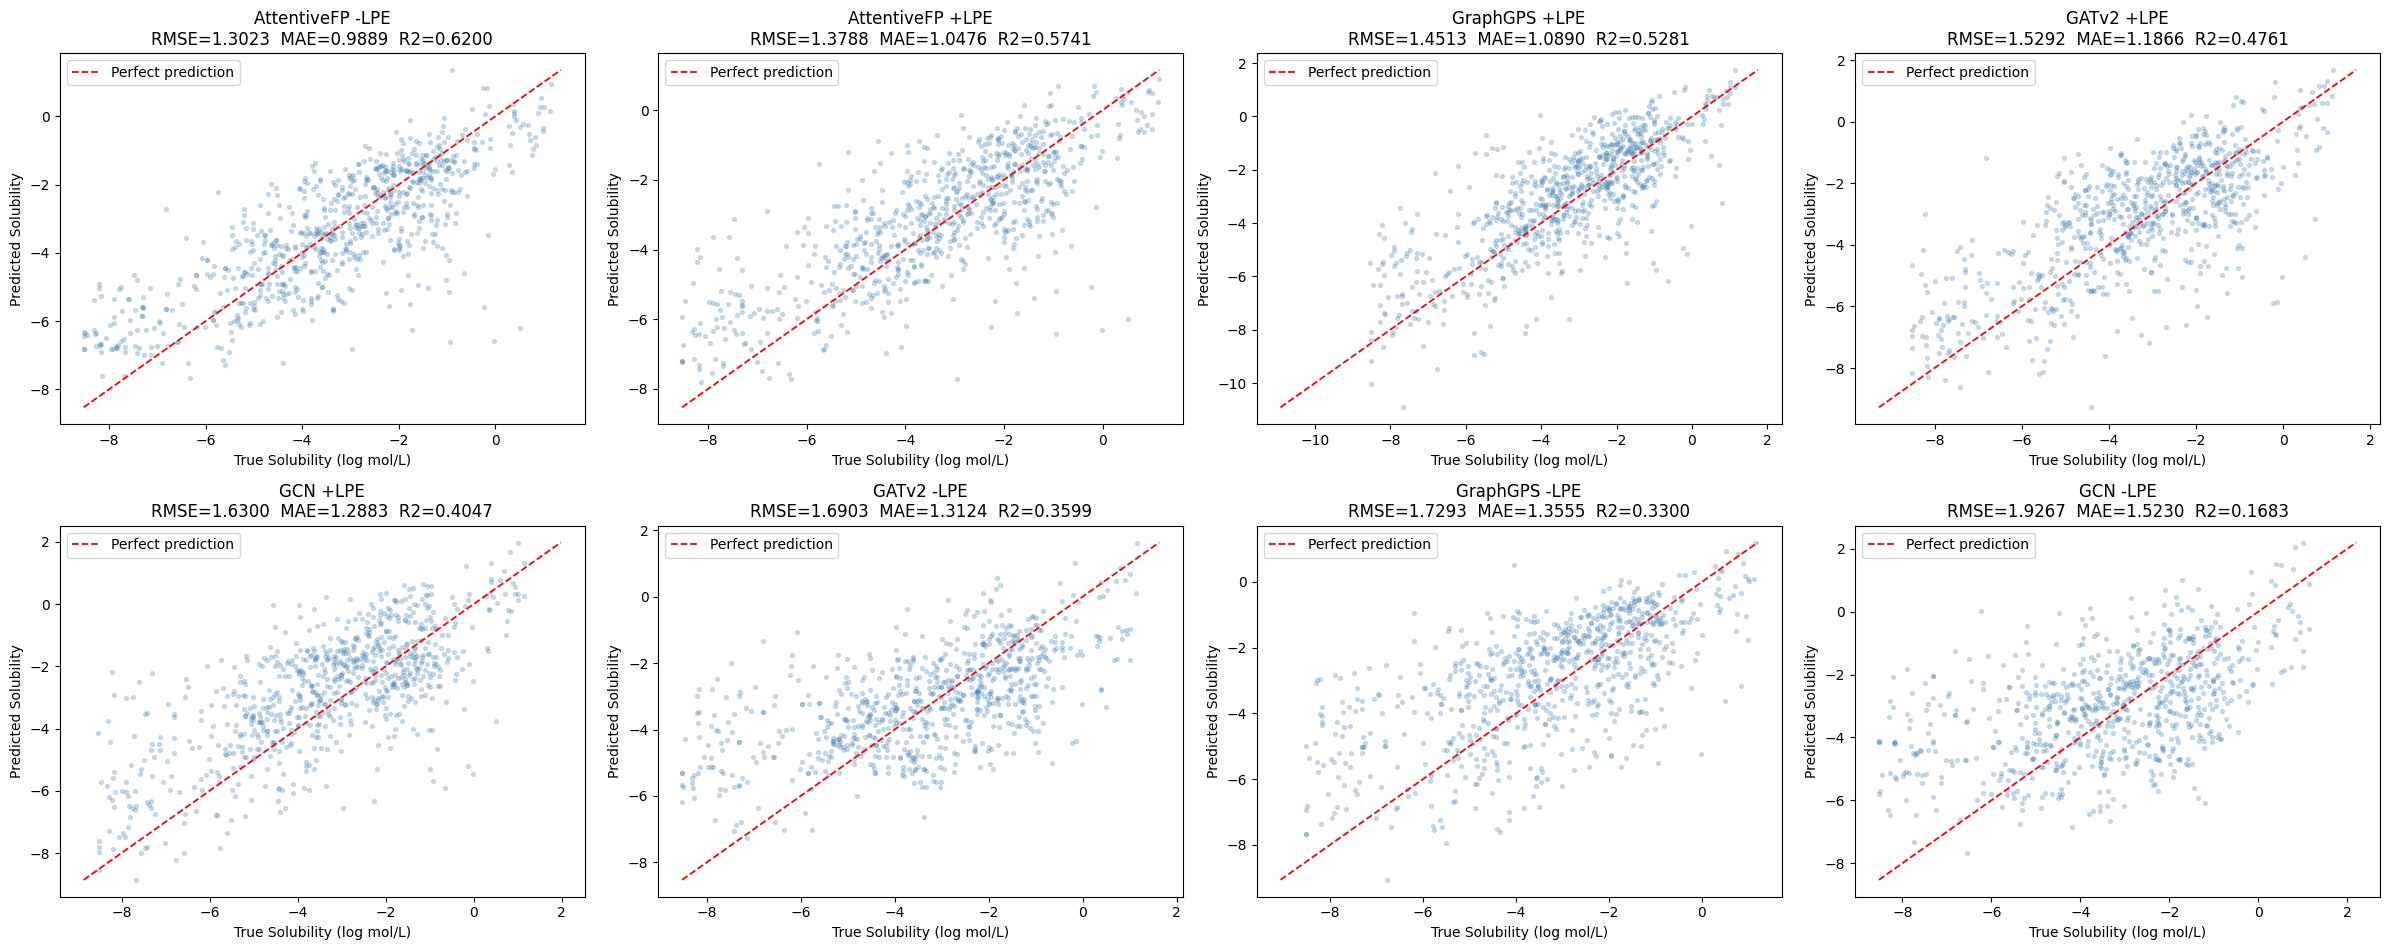

Plot saved to aqsol_pred_vs_true_all_variants.png


In [21]:
import math
import matplotlib.pyplot as plt
import numpy as np


def get_preds_targets(model, loader, device):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            preds.append(model(batch).cpu().numpy())
            targets.append(batch.y.squeeze(-1).float().cpu().numpy())
    return np.concatenate(preds), np.concatenate(targets)


_, _, plot_test_loader = make_loaders(batch_size=EXP_BATCH_SIZE, num_workers=NUM_WORKERS)
available_variants = [
    key for key in test_metrics_registry.keys()
    if key in final_model_registry
]

if len(available_variants) == 0:
    print("No trained model found. Run the four experiment cells first.")
else:
    available_variants = sorted(
        available_variants, key=lambda k: test_metrics_registry[k]["rmse"]
    )

    ncols = min(4, len(available_variants))
    nrows = math.ceil(len(available_variants) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.8 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, variant_name in zip(axes, available_variants):
        model = final_model_registry[variant_name]
        metrics = test_metrics_registry[variant_name]

        preds, targets = get_preds_targets(model, plot_test_loader, device)
        ax.scatter(targets, preds, alpha=0.25, s=8, color='steelblue')
        lims = [min(targets.min(), preds.min()), max(targets.max(), preds.max())]
        ax.plot(lims, lims, 'r--', linewidth=1.3, label='Perfect prediction')
        ax.set_xlabel("True Solubility (log mol/L)")
        ax.set_ylabel("Predicted Solubility")
        ax.set_title(
            f"{variant_name}\nRMSE={metrics['rmse']:.4f}  MAE={metrics['mae']:.4f}  R2={metrics['r2']:.4f}"
        )
        ax.legend()

    for ax in axes[len(available_variants):]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("aqsol_pred_vs_true_all_variants.png", dpi=150)
    plt.show()
    print("Plot saved to aqsol_pred_vs_true_all_variants.png")

In [22]:
payload = {
    "NODE_DIM": NODE_DIM,
    "EDGE_DIM": EDGE_DIM,
    "LAP_PE_DIM": LAP_PE_DIM,
    "fast_config": {
        "FAST_MODE": FAST_MODE,
        "EXP_BATCH_SIZE": EXP_BATCH_SIZE,
        "NUM_WORKERS": NUM_WORKERS,
        "N_TRIALS_PER_VARIANT": N_TRIALS_PER_VARIANT,
        "TUNE_EPOCHS": TUNE_EPOCHS,
        "TUNE_PATIENCE": TUNE_PATIENCE,
        "FINAL_EPOCHS": FINAL_EPOCHS,
        "FINAL_PATIENCE": FINAL_PATIENCE,
    },
    "experiment_meta_registry": experiment_meta_registry,
    "best_params_registry": best_params_registry,
    "test_metrics_registry": test_metrics_registry,
    "model_state_dicts": {
        variant_name: model.state_dict()
        for variant_name, model in final_model_registry.items()
    },
}

torch.save(payload, "aqsol_models_all_variants.pt")
print(f"Saved {len(final_model_registry)} variant model(s) to aqsol_models_all_variants.pt")

Saved 8 variant model(s) to aqsol_models_all_variants.pt
